In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import yfinance as yf
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler

import pickle
import os

# ── CONFIG ──────────────────────────────────────────────────────────────────
TICKER      = '^NSEI'          # S&P 500 ETF — change to '^GSPC' for the index itself
START_DATE  = '2000-01-01'   # Covers dot-com, GFC, COVID — important for diverse regimes
END_DATE    = '2024-12-31'
N_REGIMES   = 3              # Bull, Bear, Sideways
RANDOM_SEED = 42

# Output paths
os.makedirs('data', exist_ok=True)
os.makedirs('plots', exist_ok=True)

print(f'Config loaded: {TICKER} | {START_DATE} to {END_DATE} | {N_REGIMES} regimes')

Config loaded: ^NSEI | 2000-01-01 to 2024-12-31 | 3 regimes


In [2]:
def download_data(ticker: str, start: str, end: str) -> pd.DataFrame:
    """
    Download OHLCV data from Yahoo Finance.
    Returns a clean DataFrame with proper column names.
    """
    print(f'Downloading {ticker} data from {start} to {end}...')
    df = yf.download(ticker, start=start, end=end, auto_adjust=True, progress=False)
    
    # Flatten MultiIndex columns if present
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    
    df.index = pd.to_datetime(df.index)
    df = df.dropna()
    
    print(f'  → {len(df)} rows downloaded | {df.index[0].date()} to {df.index[-1].date()}')
    return df


# Download SPY and VIX
spy = download_data(TICKER, START_DATE, END_DATE)
vix = download_data('^INDIAVIX', START_DATE, END_DATE)

# Preview
spy.tail(3)

  → 4237 rows downloaded | 2007-09-17 to 2024-12-30
  → 4121 rows downloaded | 2008-03-03 to 2024-12-30


Price,Close,High,Low,Open,Volume
Date,,,,,
2024-12-26,23750.199219,23854.500000,23653.599609,23775.800781,177700
2024-12-27,23813.400391,23938.849609,23800.599609,23801.400391,176800
2024-12-30,23644.900391,23915.349609,23599.300781,23796.900391,364900


In [3]:
# Basic data quality checks
print('=== DATA QUALITY REPORT ===')
print(f'Shape          : {spy.shape}')
print(f'Missing values : {spy.isnull().sum().sum()}')
print(f'Date range     : {spy.index[0].date()} → {spy.index[-1].date()}')
print(f'Trading days   : {len(spy)}')
print(f'Years covered  : {len(spy)/252:.1f}')
print()

# Check for anomalies (zero volume, negative prices)
zero_vol = (spy['Volume'] == 0).sum()
neg_price = (spy['Close'] <= 0).sum()
print(f'Zero volume days  : {zero_vol}')
print(f'Non-positive price: {neg_price}')

=== DATA QUALITY REPORT ===
Shape          : (4237, 5)
Missing values : 0
Date range     : 2007-09-17 → 2024-12-30
Trading days   : 4237
Years covered  : 16.8

Zero volume days  : 1333
Non-positive price: 0


In [4]:
def compute_hmm_features(df: pd.DataFrame, vol_window: int = 21) -> pd.DataFrame:
    """
    Compute features suitable for HMM regime detection.
    
    Args:
        df         : Raw OHLCV DataFrame
        vol_window : Rolling window for realized volatility (default: 21 trading days = 1 month)
    
    Returns:
        DataFrame with engineered features, NaN rows dropped
    """
    out = pd.DataFrame(index=df.index)
    
    # Log returns — the core signal
    out['log_return'] = np.log(df['Close'] / df['Close'].shift(1))
    
    # Realized volatility: rolling std of log returns, annualized
    out['realized_vol'] = out['log_return'].rolling(vol_window).std() * np.sqrt(252)
    
    # Range: (High - Low) / Close — measures intraday uncertainty
    out['daily_range'] = (df['High'] - df['Low']) / df['Close']
    
    # Keep raw price for plotting (not fed into HMM)
    out['Close'] = df['Close']
    
    # Drop NaN rows created by rolling windows
    out = out.dropna()
    
    return out


features_df = compute_hmm_features(spy)
print(f'Feature matrix shape: {features_df.shape}')
features_df.describe().round(4)

Feature matrix shape: (4216, 4)


,log_return,realized_vol,daily_range,Close
count,4216.0000,4216.0000,4216.0000,4216.0000
mean,0.0003,0.1777,0.0145,10133.3433
std,0.0133,0.1135,0.0122,5549.0884
min,-0.1390,0.0506,0.0025,2524.2000
25%,-0.0054,0.1106,0.0077,5611.7999
50%,0.0007,0.1462,0.0111,8487.9751
75%,0.0066,0.1994,0.0169,12119.3250
max,0.1633,0.8946,0.1645,26216.0508


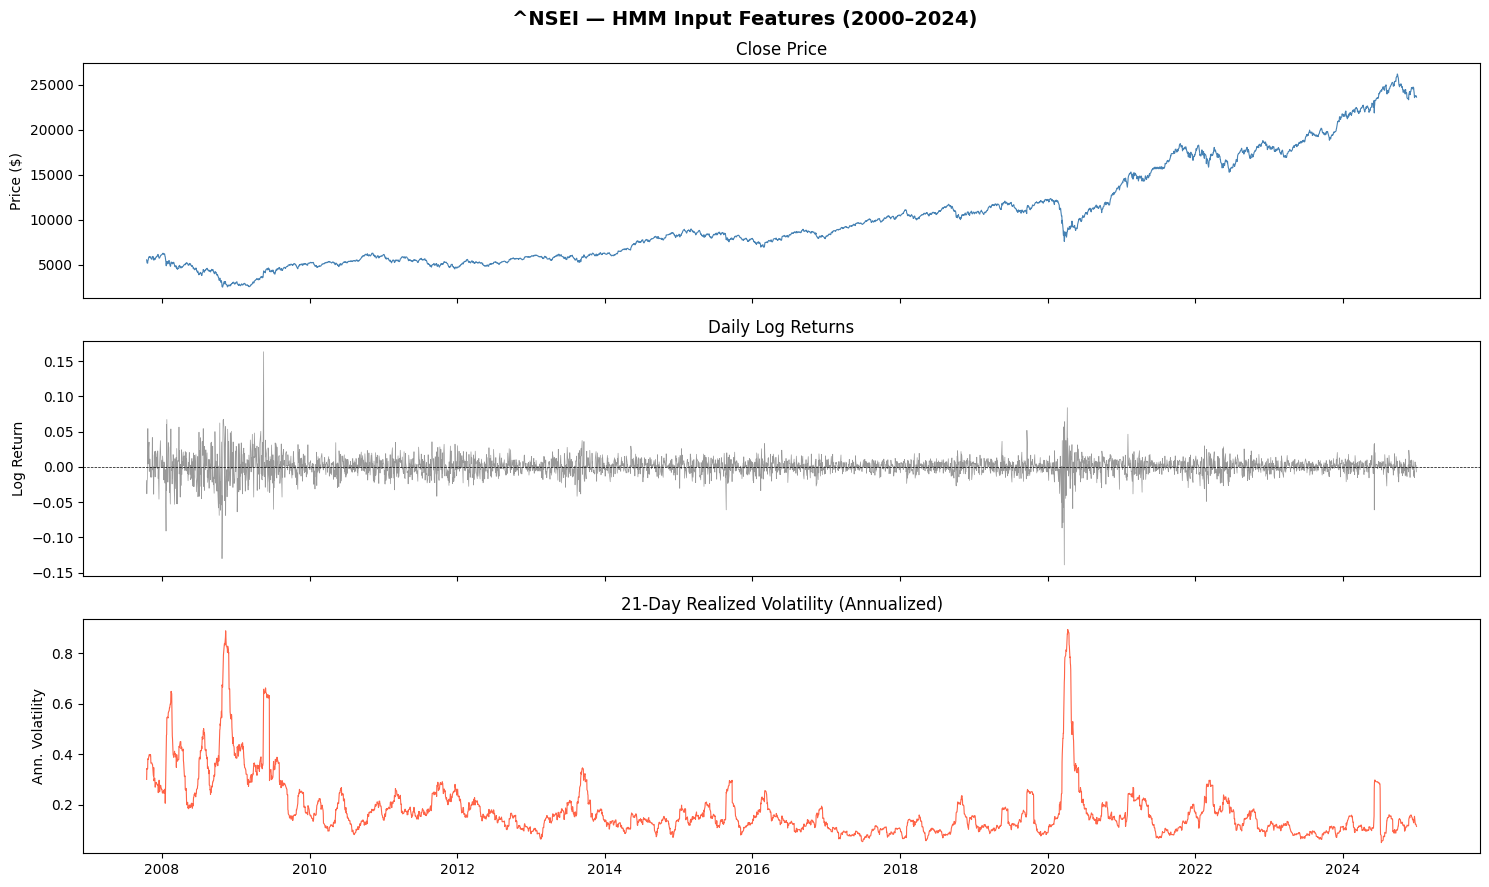

Plot saved to plots/01_raw_features.png


In [5]:
# Visualize the raw features before feeding into HMM
fig, axes = plt.subplots(3, 1, figsize=(15, 9), sharex=True)
fig.suptitle(f'{TICKER} — HMM Input Features (2000–2024)', fontsize=14, fontweight='bold')

axes[0].plot(features_df.index, features_df['Close'], color='steelblue', linewidth=0.8)
axes[0].set_ylabel('Price ($)')
axes[0].set_title('Close Price')

axes[1].plot(features_df.index, features_df['log_return'], color='gray', linewidth=0.5, alpha=0.8)
axes[1].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[1].set_ylabel('Log Return')
axes[1].set_title('Daily Log Returns')

axes[2].plot(features_df.index, features_df['realized_vol'], color='tomato', linewidth=0.8)
axes[2].set_ylabel('Ann. Volatility')
axes[2].set_title('21-Day Realized Volatility (Annualized)')

plt.tight_layout()
plt.savefig('plots/01_raw_features.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to plots/01_raw_features.png')

In [6]:
def fit_hmm(features_df: pd.DataFrame, n_states: int = 3, seed: int = 42) -> tuple:
    """
    Fit a Gaussian HMM to return features and predict regime states.
    
    Args:
        features_df : DataFrame with log_return, realized_vol, daily_range
        n_states    : Number of hidden states (regimes)
        seed        : Random seed for reproducibility
    
    Returns:
        model       : Fitted GaussianHMM
        raw_states  : Raw state labels (0, 1, 2 — not yet sorted)
        state_map   : Dict mapping raw state → regime name
    """
    # Select features to feed into HMM (do NOT include 'Close')
    hmm_features = ['log_return', 'realized_vol', 'daily_range']
    X = features_df[hmm_features].values
    
    # Standardize — HMM is sensitive to feature scale
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Fit HMM
    model = GaussianHMM(
        n_components=n_states,
        covariance_type='full',   # Full covariance matrix per state
        n_iter=1000,              # Max EM iterations
        tol=1e-4,
        random_state=seed,
        verbose=False
    )
    model.fit(X_scaled)
    
    # Decode most likely state sequence using Viterbi algorithm
    raw_states = model.predict(X_scaled)
    
    print(f'HMM converged: {model.monitor_.converged}')
    print(f'Log-likelihood: {model.score(X_scaled):.2f}')
    
    # Sort states by mean log return: lowest = Bear, highest = Bull
    state_means = {}
    for s in range(n_states):
        mask = (raw_states == s)
        state_means[s] = features_df.loc[mask, 'log_return'].mean()
    
    sorted_states = sorted(state_means, key=state_means.get)
    
    regime_names = {0: 'Bear', 1: 'Sideways', 2: 'Bull'}
    state_map = {raw: regime_names[rank] for rank, raw in enumerate(sorted_states)}
    
    print('\nState assignment (by mean return):')
    for raw_s, name in state_map.items():
        print(f'  Raw state {raw_s} → {name:8s} | mean daily return: {state_means[raw_s]*100:.3f}%')
    
    return model, raw_states, state_map, scaler


model, raw_states, state_map, scaler = fit_hmm(features_df, N_REGIMES, RANDOM_SEED)

HMM converged: True
Log-likelihood: -8767.25

State assignment (by mean return):
  Raw state 1 → Bear     | mean daily return: 0.010%
  Raw state 2 → Sideways | mean daily return: 0.039%
  Raw state 0 → Bull     | mean daily return: 0.055%


In [7]:
# Map raw integer states to regime names and numeric codes
REGIME_CODE = {'Bear': 0, 'Sideways': 1, 'Bull': 2}
REGIME_COLOR = {'Bear': '#e74c3c', 'Sideways': '#f39c12', 'Bull': '#2ecc71'}

features_df['regime_raw']  = raw_states
features_df['regime_name'] = features_df['regime_raw'].map(state_map)
features_df['regime_code'] = features_df['regime_name'].map(REGIME_CODE)

# Distribution of regimes
regime_counts = features_df['regime_name'].value_counts()
print('=== REGIME DISTRIBUTION ===')
for regime, count in regime_counts.items():
    pct = count / len(features_df) * 100
    print(f'  {regime:8s}: {count:5d} days ({pct:.1f}%)')

features_df[['Close', 'log_return', 'realized_vol', 'regime_name', 'regime_code']].tail(5)

=== REGIME DISTRIBUTION ===
  Bull    :  1727 days (41.0%)
  Bear    :  1697 days (40.3%)
  Sideways:   792 days (18.8%)


,Close,log_return,realized_vol,regime_name,regime_code
Date,,,,,
2024-12-23,23753.449219,0.007011,0.132745,Bull,2
2024-12-24,23727.650391,-0.001087,0.123498,Bull,2
2024-12-26,23750.199219,0.000950,0.123677,Bull,2
2024-12-27,23813.400391,0.002658,0.123415,Bull,2
2024-12-30,23644.900391,-0.007101,0.114831,Bull,2


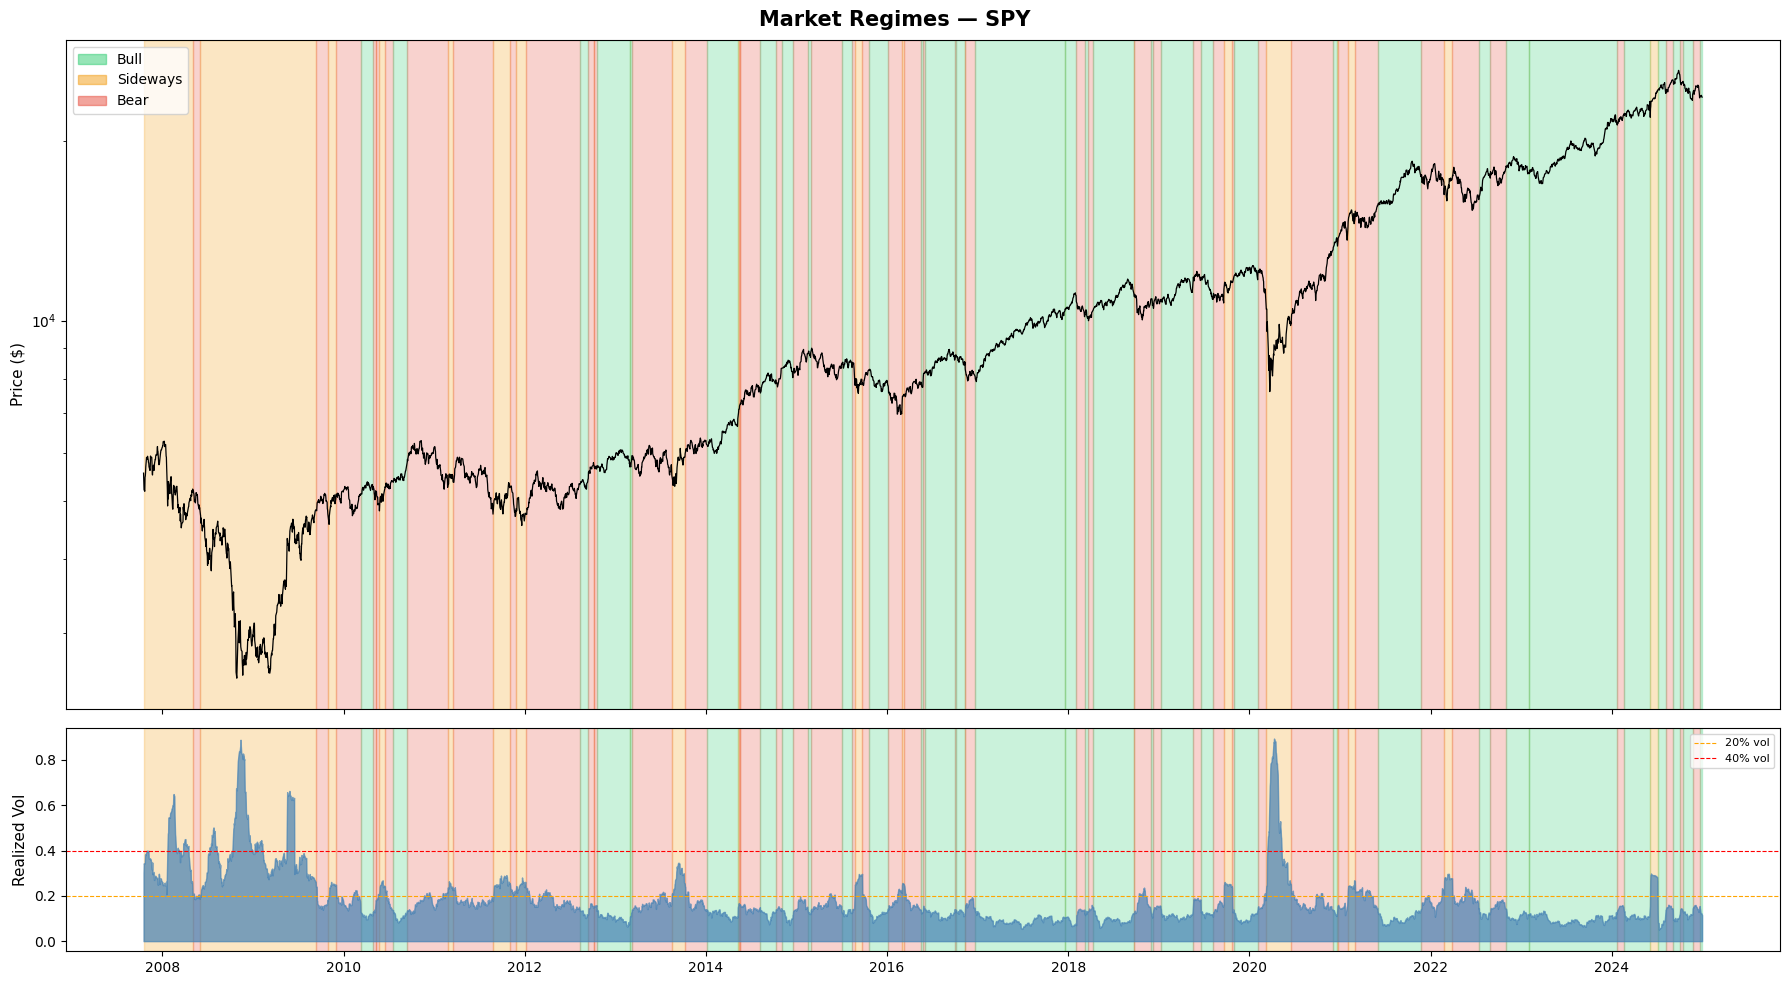

Plot saved to plots/02_regime_overlay.png


In [8]:
def plot_regimes_matplotlib(df: pd.DataFrame, title: str = 'Market Regimes — SPY'):
    """
    Plot price chart with regime background shading.
    """
    fig, axes = plt.subplots(2, 1, figsize=(18, 10), sharex=True,
                              gridspec_kw={'height_ratios': [3, 1]})
    fig.suptitle(title, fontsize=15, fontweight='bold')
    
    ax1, ax2 = axes
    
    # Price
    ax1.plot(df.index, df['Close'], color='black', linewidth=0.9, zorder=5)
    ax1.set_ylabel('Price ($)', fontsize=11)
    ax1.set_yscale('log')  # Log scale shows proportional moves better
    
    # Regime background shading
    prev_regime = None
    start_idx = None
    
    for i, (date, row) in enumerate(df.iterrows()):
        regime = row['regime_name']
        if regime != prev_regime:
            if prev_regime is not None:
                for ax in [ax1, ax2]:
                    ax.axvspan(start_idx, date, alpha=0.25,
                               color=REGIME_COLOR[prev_regime], zorder=1)
            start_idx = date
            prev_regime = regime
    # Final segment
    if prev_regime is not None:
        for ax in [ax1, ax2]:
            ax.axvspan(start_idx, df.index[-1], alpha=0.25,
                       color=REGIME_COLOR[prev_regime], zorder=1)
    
    # Volatility panel
    ax2.fill_between(df.index, df['realized_vol'], alpha=0.7, color='steelblue')
    ax2.set_ylabel('Realized Vol', fontsize=11)
    ax2.axhline(0.2, color='orange', linestyle='--', linewidth=0.8, label='20% vol')
    ax2.axhline(0.4, color='red',    linestyle='--', linewidth=0.8, label='40% vol')
    ax2.legend(loc='upper right', fontsize=8)
    
    # Legend
    patches = [mpatches.Patch(color=REGIME_COLOR[r], alpha=0.5, label=r)
               for r in ['Bull', 'Sideways', 'Bear']]
    ax1.legend(handles=patches, loc='upper left', fontsize=10)
    
    plt.tight_layout()
    plt.savefig('plots/02_regime_overlay.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Plot saved to plots/02_regime_overlay.png')


plot_regimes_matplotlib(features_df)

In [9]:
# Interactive Plotly chart (much easier to zoom and inspect)
def plot_regimes_plotly(df: pd.DataFrame):
    fig = make_subplots(
        rows=2, cols=1, shared_xaxes=True,
        row_heights=[0.7, 0.3],
        subplot_titles=['SPY Price + Regimes', 'Realized Volatility']
    )
    
    # Price line
    fig.add_trace(go.Scatter(
        x=df.index, y=df['Close'],
        name='SPY', line=dict(color='black', width=1)
    ), row=1, col=1)
    
    # Regime colored scatter dots
    for regime_name, color in REGIME_COLOR.items():
        mask = df['regime_name'] == regime_name
        fig.add_trace(go.Scatter(
            x=df.index[mask], y=df['Close'][mask],
            name=regime_name, mode='markers',
            marker=dict(size=2, color=color),
            showlegend=True
        ), row=1, col=1)
    
    # Volatility
    fig.add_trace(go.Scatter(
        x=df.index, y=df['realized_vol'],
        name='21D Vol', fill='tozeroy',
        line=dict(color='steelblue', width=1)
    ), row=2, col=1)
    
    fig.update_layout(
        title='Market Regime Detection — SPY (2000–2024)',
        height=700,
        xaxis_rangeslider_visible=False
    )
    fig.update_yaxes(type='log', row=1, col=1)
    fig.show()


plot_regimes_plotly(features_df)

In [10]:
def compute_regime_stats(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute descriptive statistics for each regime.
    This is a critical sanity check — regimes should be economically distinct.
    """
    stats = {}
    
    for regime in ['Bull', 'Sideways', 'Bear']:
        mask = df['regime_name'] == regime
        sub = df[mask]
        rets = sub['log_return']
        
        stats[regime] = {
            'Days'              : len(sub),
            'Pct of History'    : f"{len(sub)/len(df)*100:.1f}%",
            'Mean Daily Ret'    : f"{rets.mean()*100:.3f}%",
            'Ann. Return'       : f"{rets.mean()*252*100:.1f}%",
            'Daily Vol'         : f"{rets.std()*100:.3f}%",
            'Ann. Volatility'   : f"{rets.std()*np.sqrt(252)*100:.1f}%",
            'Sharpe (ann)'      : f"{(rets.mean()/rets.std())*np.sqrt(252):.2f}",
            'Max Daily Loss'    : f"{rets.min()*100:.2f}%",
            'Max Daily Gain'    : f"{rets.max()*100:.2f}%",
            'Skewness'          : f"{rets.skew():.2f}",
            'Kurtosis'          : f"{rets.kurt():.2f}",
        }
    
    return pd.DataFrame(stats)


regime_stats = compute_regime_stats(features_df)
print('=== REGIME STATISTICS ===')
regime_stats

=== REGIME STATISTICS ===


,Bull,Sideways,Bear
Days,1727,792,1697
Pct of History,41.0%,18.8%,40.3%
Mean Daily Ret,0.055%,0.039%,0.010%
Ann. Return,13.9%,9.9%,2.4%
Daily Vol,0.657%,2.448%,1.068%
Ann. Volatility,10.4%,38.9%,17.0%
Sharpe (ann),1.33,0.25,0.14
Max Daily Loss,-2.22%,-13.90%,-3.78%
Max Daily Gain,2.05%,16.33%,3.63%
Skewness,-0.13,-0.22,-0.18


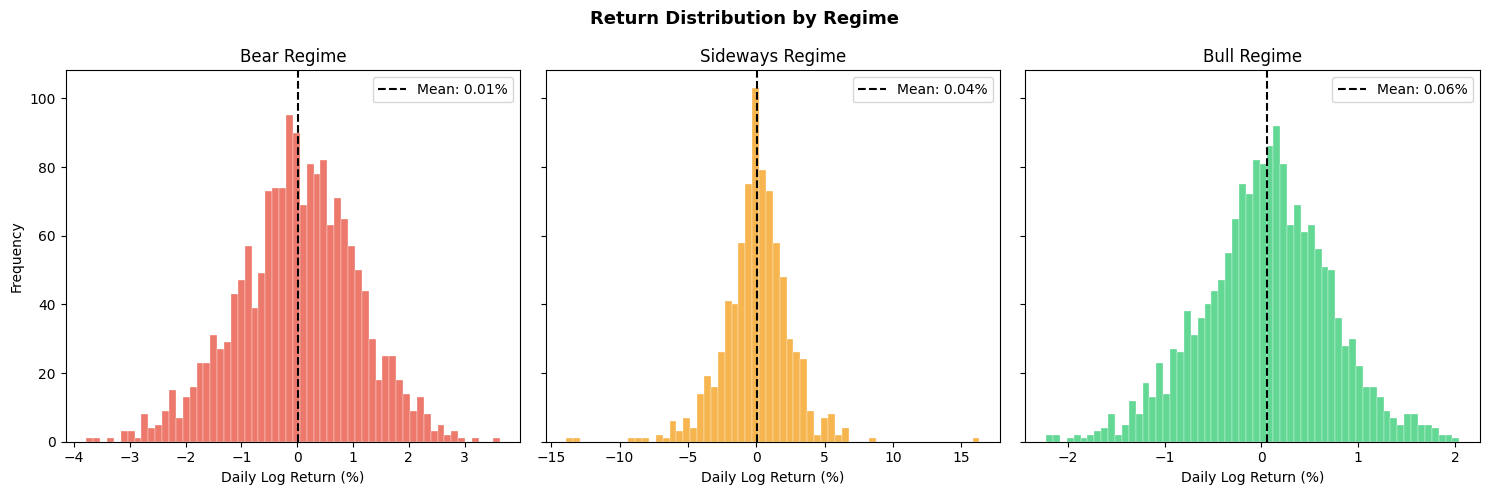

In [11]:
# Return distribution per regime
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
fig.suptitle('Return Distribution by Regime', fontsize=13, fontweight='bold')

for ax, regime in zip(axes, ['Bear', 'Sideways', 'Bull']):
    mask = features_df['regime_name'] == regime
    data = features_df.loc[mask, 'log_return'] * 100
    ax.hist(data, bins=60, color=REGIME_COLOR[regime], alpha=0.75, edgecolor='white', linewidth=0.3)
    ax.axvline(data.mean(), color='black', linestyle='--', linewidth=1.5, label=f'Mean: {data.mean():.2f}%')
    ax.set_title(f'{regime} Regime', fontsize=12)
    ax.set_xlabel('Daily Log Return (%)')
    ax.legend()

axes[0].set_ylabel('Frequency')
plt.tight_layout()
plt.savefig('plots/03_regime_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
def prepare_labeled_dataset(features_df: pd.DataFrame, vix_df: pd.DataFrame) -> pd.DataFrame:
    """
    Build the final labeled dataset:
    - Add VIX as a feature (aligned to feature_df dates)
    - Add lagged returns
    - Create forward-shifted target (predict TOMORROW's regime)
    - Drop NaN rows
    """
    df = features_df.copy()
    
    # Add VIX
    vix_close = vix_df['Close'].rename('vix')
    df = df.join(vix_close, how='left')
    df['vix'] = df['vix'].ffill()  # Forward fill missing VIX days
    
    # Lagged returns (no lookahead — lag=1 means yesterday's return)
    for lag in [1, 2, 3, 5]:
        df[f'ret_lag{lag}'] = df['log_return'].shift(lag)
    
    # Rolling means
    df['ret_5d_mean']  = df['log_return'].rolling(5).mean().shift(1)
    df['ret_21d_mean'] = df['log_return'].rolling(21).mean().shift(1)
    
    # ─── TARGET: shift regime forward by 1 (predict tomorrow's regime) ───
    df['target_regime_code'] = df['regime_code'].shift(-1)
    df['target_regime_name'] = df['regime_name'].shift(-1)
    
    # Drop rows with NaN (from lags and the final row where target is NaN)
    df = df.dropna()
    
    print(f'Final dataset shape : {df.shape}')
    print(f'Date range          : {df.index[0].date()} → {df.index[-1].date()}')
    print(f'Target distribution :')
    print(df['target_regime_name'].value_counts())
    
    return df


labeled_df = prepare_labeled_dataset(features_df, vix)
labeled_df.tail(3)

Final dataset shape : (4120, 16)
Date range          : 2008-03-03 → 2024-12-27
Target distribution :
target_regime_name
Bull        1727
Bear        1697
Sideways     696
Name: count, dtype: int64


,log_return,realized_vol,daily_range,Close,regime_raw,regime_name,regime_code,vix,ret_lag1,ret_lag2,ret_lag3,ret_lag5,ret_5d_mean,ret_21d_mean,target_regime_code,target_regime_name
Date,,,,,,,,,,,,,,,,
2024-12-24,-0.001087,0.123498,0.007691,23727.650391,0,Bull,2,13.18,0.007011,-0.015322,-0.010266,-0.013560,-0.007558,-0.000307,2.0,Bull
2024-12-26,0.000950,0.123677,0.008459,23750.199219,0,Bull,2,14.04,-0.001087,0.007011,-0.015322,-0.005652,-0.005063,-0.000982,2.0,Bull
2024-12-27,0.002658,0.123415,0.005806,23813.400391,0,Bull,2,13.24,0.000950,-0.001087,0.007011,-0.010266,-0.003743,-0.000883,2.0,Bull


In [13]:
# Save labeled dataset for Notebook 02
labeled_df.to_csv('data/01_labeled_regimes.csv')

# Save HMM model and scaler for reuse (inference in deployment)
with open('data/hmm_model.pkl', 'wb') as f:
    pickle.dump({'model': model, 'scaler': scaler, 'state_map': state_map}, f)

print('✅ Saved: data/01_labeled_regimes.csv')
print('✅ Saved: data/hmm_model.pkl')
print()
print('=== FINAL COLUMN REFERENCE ===')
for col in labeled_df.columns:
    print(f'  {col}')

✅ Saved: data/01_labeled_regimes.csv
✅ Saved: data/hmm_model.pkl

=== FINAL COLUMN REFERENCE ===
  log_return
  realized_vol
  daily_range
  Close
  regime_raw
  regime_name
  regime_code
  vix
  ret_lag1
  ret_lag2
  ret_lag3
  ret_lag5
  ret_5d_mean
  ret_21d_mean
  target_regime_code
  target_regime_name
